# Step 6 — Climate controls on the 30-year runoff partition

**English.** This notebook extends the Case A climatological analysis with eight CMIP6 variables downloaded from ESGF for the same model, experiment, member, grid, and 1985–2014 period. It asks which large-scale climate states co-vary with the long-term runoff fraction, $R/P$. The workflow is descriptive EDA, not causal attribution and not yet a tree model.

**中文。** 本 notebook 在 Case A 的 30 年气候态分析基础上，加入从 ESGF 下载的 8 个 CMIP6 变量。模型、实验、成员、网格和时段均与已有数据一致。这里关注哪些气候状态与长期径流比例 $R/P$ 同时变化。当前步骤只是描述性 EDA，不做因果归因，也暂时不训练 tree。

## 1. Analysis design / 分析设计

**English**

- Target: the ratio of 30-year mean runoff to 30-year mean precipitation, rather than the mean of annual ratios.
- Predictors: precipitation, near-surface air temperature, net surface radiation, total soil moisture, surface soil moisture, and snow water equivalent.
- Net surface radiation is derived as $R_n=(rsds-rsus)+(rlds-rlus)$. Positive values indicate net energy into the surface.
- Monthly values are weighted by days per month before calculating the 1985–2014 climatology.
- The analysis uses only the previously defined non-ice terrestrial cells. Land area supplies the spatial weights.
- We report marginal area-weighted Spearman correlations and partial rank correlations after controlling for $\log_{10}(P)$. The latter helps separate a driver's relationship from the broad wet–dry precipitation gradient.

**中文**

- 目标变量是“30 年平均径流 / 30 年平均降水”，而不是逐年比例再平均。
- 解释变量包括降水、近地面气温、地表净辐射、总土壤水分、表层土壤水分和雪水当量。
- 地表净辐射定义为 $R_n=(rsds-rsus)+(rlds-rlus)$；正值表示地表获得净能量。
- 先用每个月的天数加权，再计算 1985–2014 的气候平均。
- 只保留前面已经确定的无冰陆地网格，并使用陆地面积作为空间权重。
- 同时计算普通的面积加权 Spearman 相关，以及控制 $\log_{10}(P)$ 后的秩偏相关。后者用于减少大尺度干湿梯度的混杂，但仍然不能代表因果关系。

In [1]:
from pathlib import Path
import glob
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="ticks", context="notebook")
plt.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 220,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "font.family": "DejaVu Sans", "axes.edgecolor": "#30343B",
    "axes.linewidth": 0.9, "axes.titlesize": 11,
    "axes.titleweight": "semibold", "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
})

START_YEAR, END_YEAR = 1985, 2014
ZONE_ORDER = ["WW", "WD", "CW", "CD"]
ZONE_LABELS = {"WW": "Warm–Wet", "WD": "Warm–Dry", "CW": "Cold–Wet", "CD": "Cold–Dry"}
ZONE_COLORS = {"WW": "#078C78", "WD": "#A85F12", "CW": "#73C9C2", "CD": "#DFC27D"}
DRIVER_SPECS = {
    "tas": ("tas_C", "Near-surface temperature", "°C"),
    "net_radiation": ("net_radiation", "Net surface radiation", "W m⁻²"),
    "mrso": ("mrso", "Total soil moisture", "kg m⁻²"),
    "mrsos": ("mrsos", "Surface soil moisture", "kg m⁻²"),
    "snw": ("snw", "Snow water equivalent", "kg m⁻²"),
}

def find_case_dir(start=Path.cwd()):
    start = start.resolve()
    for base in (start, *start.parents):
        if base.name.lower() == "casea":
            return base
        candidate = base / "case" / "caseA"
        if candidate.exists():
            return candidate
    raise FileNotFoundError("Could not locate case/caseA.")

def style_axes(ax):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("#30343B")
        spine.set_linewidth(0.9)
    ax.tick_params(direction="out", length=3.5, width=0.75, color="#30343B")
    ax.grid(True, color="#D3D3D3", linewidth=0.8, alpha=0.80, zorder=0)

CASE_DIR = find_case_dir()
RAW_DIR = CASE_DIR / "drivers" / "raw"
DERIVED_DIR = CASE_DIR / "derived"
FIGURE_DIR = DERIVED_DIR / "figures_step6"
WATER_NC = DERIVED_DIR / "MPI_ESM1_2_LR_climatology_partition_1985_2014.nc"
ZONE_TABLE = DERIVED_DIR / "MPI_ESM1_2_LR_koppen_zone_climatology_1985_2014.parquet"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
print(f"Case directory: {CASE_DIR}")
print(f"Driver directory: {RAW_DIR}")

Case directory: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA
Driver directory: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/drivers/raw


## 2. Load and audit the downloaded CMIP6 files / 读取并检查下载数据

**English.** Every variable must contain 360 monthly values from January 1985 through December 2014 after subsetting. We also test coordinate equality against the existing water-cycle grid before joining any values.

**中文。** 截取以后，每个变量都必须包含 1985 年 1 月至 2014 年 12 月的 360 个月。任何数值合并之前，还要检查这些变量的经纬度是否与已有水循环数据完全一致。

In [2]:
VARIABLES = ["tas", "rsds", "rsus", "rlds", "rlus", "mrso", "mrsos", "snw"]

def open_driver(variable):
    paths = sorted((RAW_DIR / variable).glob("*.nc"))
    if not paths:
        raise FileNotFoundError(f"No downloaded files found for {variable}")
    ds = xr.open_mfdataset(paths, combine="by_coords")
    da = ds[variable].sel(time=slice(f"{START_YEAR}-01-01", f"{END_YEAR}-12-31"))
    da = da.assign_coords(lon=((da.lon + 180) % 360) - 180).sortby("lon")
    return da

monthly = {variable: open_driver(variable) for variable in VARIABLES}
water = xr.open_dataset(WATER_NC)

audit_rows = []
for variable, da in monthly.items():
    same_grid = np.allclose(da.lat, water.lat) and np.allclose(da.lon, water.lon)
    audit_rows.append({
        "variable": variable, "months": da.sizes["time"],
        "first_month": str(da.time.values[0])[:10],
        "last_month": str(da.time.values[-1])[:10],
        "units": da.attrs.get("units", ""), "same_grid": same_grid,
    })
audit = pd.DataFrame(audit_rows)
display(audit)
assert (audit["months"] == 360).all(), "Expected exactly 360 months per variable."
assert audit["same_grid"].all(), "A downloaded driver does not match the water-cycle grid."

,variable,months,first_month,last_month,units,same_grid
0,tas,360,1985-01-16,2014-12-16,K,True
1,rsds,360,1985-01-16,2014-12-16,W m-2,True
2,rsus,360,1985-01-16,2014-12-16,W m-2,True
3,rlds,360,1985-01-16,2014-12-16,W m-2,True
4,rlus,360,1985-01-16,2014-12-16,W m-2,True
5,mrso,360,1985-01-16,2014-12-16,kg m-2,True
6,mrsos,360,1985-01-16,2014-12-16,kg m-2,True
7,snw,360,1985-01-16,2014-12-16,kg m-2,True


## 3. Build the 1985–2014 driver climatology / 构建 1985–2014 驱动变量气候态

**English.** Months have unequal lengths, so a February mean should not receive the same temporal weight as a 31-day month. The calculation below uses calendar-day weights. Temperature is additionally converted from kelvin to degrees Celsius. Radiation remains in W m⁻², while soil moisture and snow remain in kg m⁻².

**中文。** 月份长度不同，因此 2 月平均值不应与 31 天月份获得完全相同的时间权重。下面使用每月天数进行加权。气温由 K 转换为 °C；辐射保持 W m⁻²，土壤水分与雪水当量保持 kg m⁻²。

In [3]:
def day_weighted_climatology(da):
    weights = da.time.dt.days_in_month.astype("float64")
    return da.weighted(weights).mean("time")

driver_clim = xr.Dataset({variable: day_weighted_climatology(da) for variable, da in monthly.items()})
driver_clim["tas_C"] = driver_clim["tas"] - 273.15
driver_clim["net_shortwave"] = driver_clim["rsds"] - driver_clim["rsus"]
driver_clim["net_longwave"] = driver_clim["rlds"] - driver_clim["rlus"]
driver_clim["net_radiation"] = driver_clim["net_shortwave"] + driver_clim["net_longwave"]
driver_clim["analysis_cell"] = water["analysis_cell"]
driver_clim.attrs.update({
    "title": "MPI-ESM1-2-LR climate-driver climatology",
    "analysis_period": "1985-2014",
    "temporal_weighting": "days in month",
    "net_radiation_definition": "(rsds-rsus)+(rlds-rlus)",
})

CLIM_OUTPUT = DERIVED_DIR / "MPI_ESM1_2_LR_climate_drivers_1985_2014.nc"
save_clim = driver_clim.copy()
for name in save_clim.data_vars:
    if name != "analysis_cell":
        save_clim[name] = save_clim[name].astype("float32")
save_clim.to_netcdf(CLIM_OUTPUT)
print(f"Saved: {CLIM_OUTPUT}")

/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_19672/773341460.py:23: SerializationWarning: saving variable analysis_cell with floating point data as an integer dtype without any _FillValue to use for NaNs
  save_clim.to_netcdf(CLIM_OUTPUT)
/Users/mimi/miniconda3/envs/pip39/lib/python3.9/site-packages/xarray/coding/variables.py:666: RuntimeWarning: invalid value encountered in cast
  data = data.astype(dtype=dtype)


Saved: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/derived/MPI_ESM1_2_LR_climate_drivers_1985_2014.nc


## 4. Join drivers to the non-ice land table / 将驱动变量合并到无冰陆地表

**English.** Values are extracted by the integer grid identifier already created in Step 4. This avoids a floating-point latitude/longitude merge. The resulting table has one row per non-ice terrestrial grid cell.

**中文。** 这里使用 Step 4 已经建立的整数网格编号提取变量，避免直接用浮点经纬度合并造成错位。最终表格中，每一行代表一个无冰陆地网格。

In [4]:
grid = pd.read_parquet(ZONE_TABLE).copy()
grid_ids = water["grid_id"].values.astype(int)
max_id = int(grid["grid_id_numeric"].max())

def extract_by_grid_id(da):
    lookup = np.full(max_id + 1, np.nan, dtype="float64")
    valid = grid_ids > 0
    lookup[grid_ids[valid]] = da.values[valid]
    return lookup[grid["grid_id_numeric"].astype(int).to_numpy()]

for name in ["tas_C", "net_shortwave", "net_longwave", "net_radiation", "mrso", "mrsos", "snw"]:
    grid[name] = extract_by_grid_id(driver_clim[name])

required = ["R_fraction_climatology", "P", "land_area", "zone", "tas_C", "net_radiation", "mrso", "mrsos", "snw"]
analysis = grid.dropna(subset=required).copy()
analysis["zone"] = pd.Categorical(analysis["zone"], categories=ZONE_ORDER, ordered=True)
analysis["log10_P"] = np.log10(analysis["P"].clip(lower=1.0))

TABLE_OUTPUT = DERIVED_DIR / "MPI_ESM1_2_LR_climate_driver_grid_1985_2014.parquet"
analysis.to_parquet(TABLE_OUTPUT, index=False)
print(f"Analysis cells: {len(analysis):,}")
print(f"Saved: {TABLE_OUTPUT}")
display(analysis[["P", "R_fraction_climatology", "tas_C", "net_radiation", "mrso", "mrsos", "snw"]].describe().T)

Analysis cells: 4,172
Saved: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/derived/MPI_ESM1_2_LR_climate_driver_grid_1985_2014.parquet


,count,mean,std,min,25%,50%,75%,max
P,4172.0,739.422058,563.274536,0.363837,347.126060,641.003998,980.327499,3543.200195
R_fraction_climatology,4172.0,0.243887,0.210957,0.003146,0.064430,0.162744,0.414485,0.866150
tas_C,4172.0,9.931528,13.184761,-19.129029,-1.533095,10.616087,22.377611,32.660408
net_radiation,4172.0,77.677395,39.235594,8.516440,44.858809,69.854257,109.266137,169.266115
mrso,4172.0,608.500967,622.417362,4.314691,148.529053,386.811926,856.720073,3847.105101
mrsos,4172.0,19.667345,8.710869,2.810613,13.245540,19.076326,26.033195,61.386999
snw,4172.0,16.514268,27.159929,0.000000,0.000000,0.323891,31.339137,244.636344


## 5. Spatial patterns / 空间分布

**English.** These Robinson maps provide the spatial sanity check. If a predictor has an implausible pattern, the relationship statistics should not be interpreted. Snow is displayed as $\log_{10}(1+snw)$ because its distribution is extremely right-skewed.

**中文。** Robinson 投影地图首先用于空间合理性检查。如果某个解释变量的空间格局明显不合理，后续相关结果就不应解释。雪水当量的分布高度右偏，因此地图显示 $\log_{10}(1+snw)$。

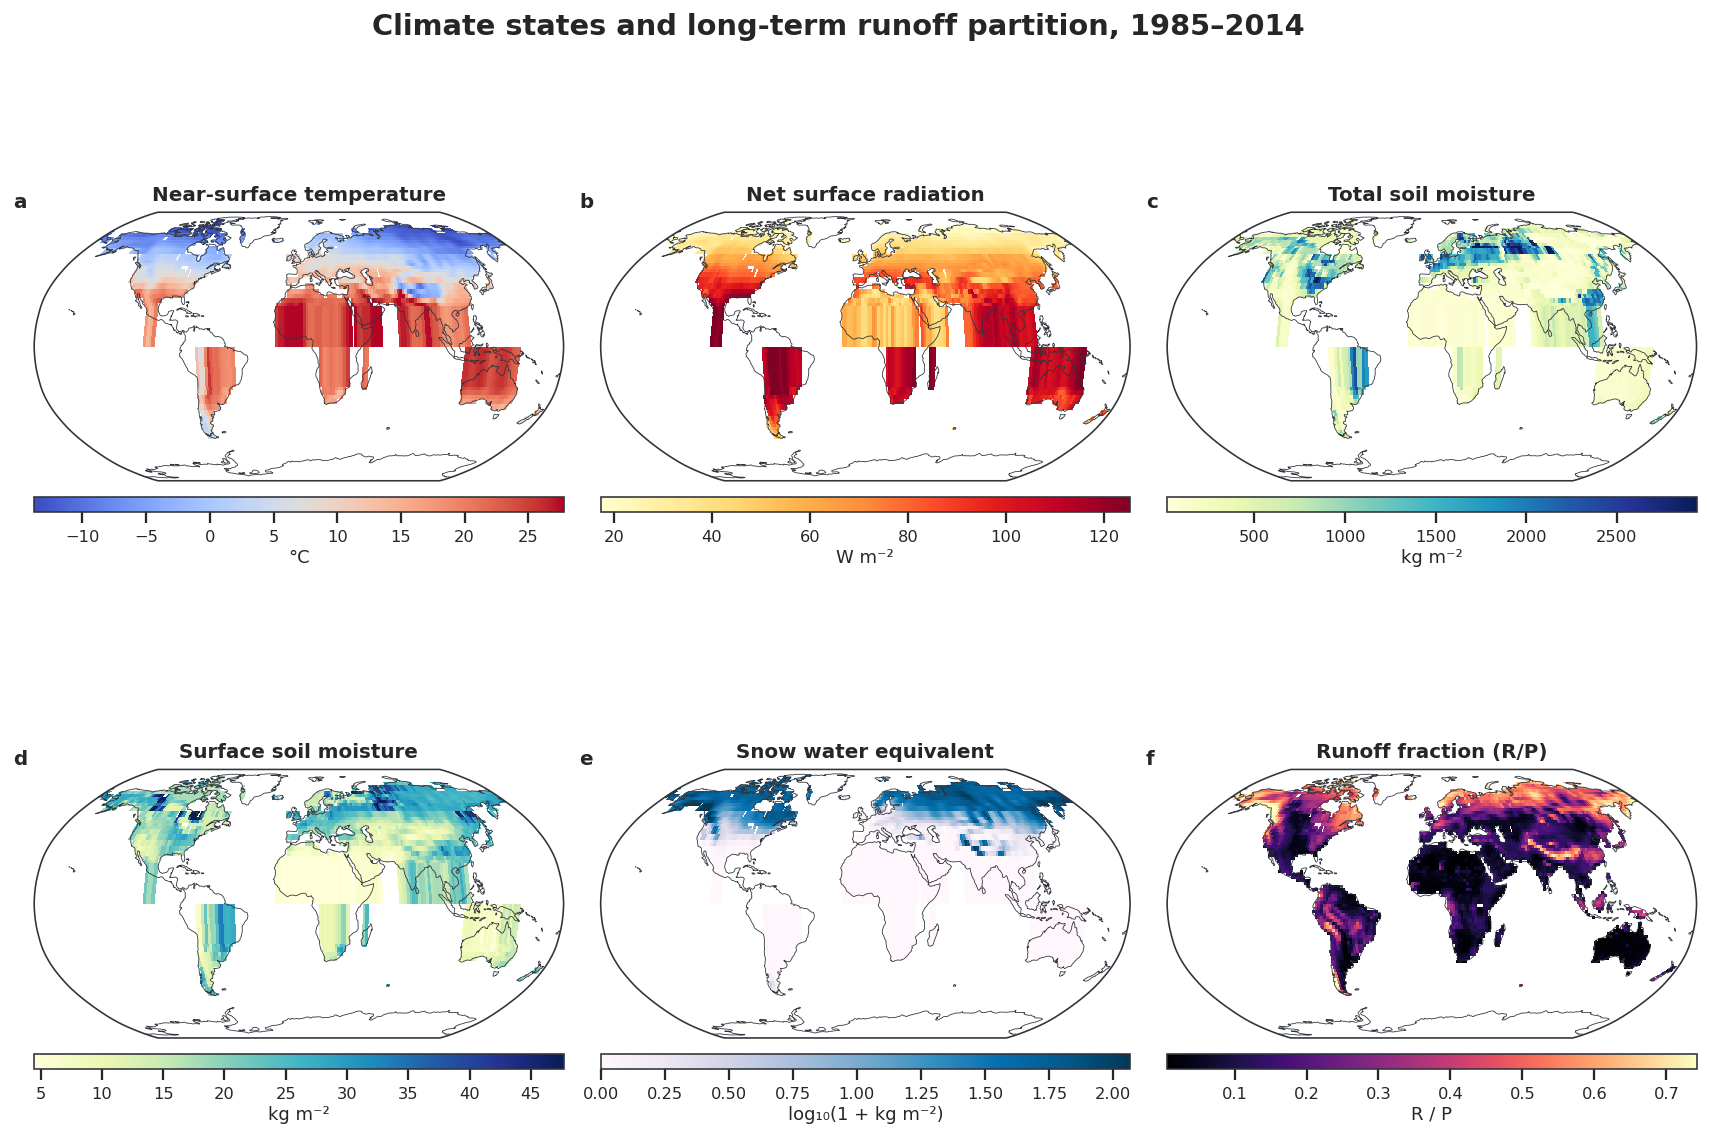

Saved: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/derived/figures_step6/climate_driver_maps.png


In [5]:
map_specs = [
    (driver_clim["tas_C"], "Near-surface temperature", "°C", "coolwarm"),
    (driver_clim["net_radiation"], "Net surface radiation", "W m⁻²", "YlOrRd"),
    (driver_clim["mrso"], "Total soil moisture", "kg m⁻²", "YlGnBu"),
    (driver_clim["mrsos"], "Surface soil moisture", "kg m⁻²", "YlGnBu"),
    (np.log10(1 + driver_clim["snw"]), "Snow water equivalent", "log₁₀(1 + kg m⁻²)", "PuBu"),
    (water["R_fraction_climatology"], "Runoff fraction (R/P)", "R / P", "magma"),
]
mask = water["analysis_cell"] == 1
fig, axes = plt.subplots(2, 3, figsize=(16.5, 8.8), subplot_kw={"projection": ccrs.Robinson()})
letters = list("abcdef")
for ax, (da, title, unit, cmap), letter in zip(axes.flat, map_specs, letters):
    values = da.where(mask)
    finite = values.values[np.isfinite(values.values)]
    vmin, vmax = np.nanpercentile(finite, [1, 99])
    mesh = ax.pcolormesh(values.lon, values.lat, values, transform=ccrs.PlateCarree(), cmap=cmap, vmin=vmin, vmax=vmax, shading="auto", rasterized=True)
    ax.coastlines(linewidth=0.45, color="#30343B")
    ax.set_global()
    ax.set_title(title, pad=7)
    ax.text(-0.04, 1.02, letter, transform=ax.transAxes, fontsize=11, fontweight="bold")
    cb = fig.colorbar(mesh, ax=ax, orientation="horizontal", pad=0.040, fraction=0.040, aspect=35)
    cb.set_label(unit, labelpad=2)
fig.suptitle("Climate states and long-term runoff partition, 1985–2014", fontsize=16, fontweight="bold", y=0.985)
fig.subplots_adjust(top=0.90, bottom=0.06, hspace=0.38, wspace=0.07)
path = FIGURE_DIR / "climate_driver_maps.png"
fig.savefig(path, bbox_inches="tight")
plt.show()
print(f"Saved: {path}")

## 6. Marginal and precipitation-controlled relationships / 普通相关与控制降水后的关系

**English.** Area-weighted Spearman correlation describes a monotonic spatial association. Partial rank correlation first removes the linear rank relationship with $\log_{10}(P)$ from both variables and then correlates the residuals. A large change between the two panels means that precipitation regime explains much of the apparent relationship. Values should be interpreted as spatial association within this one ESM simulation.

**中文。** 面积加权 Spearman 相关描述空间上的单调关系。秩偏相关先从目标变量和解释变量中分别去除与 $\log_{10}(P)$ 的线性秩关系，然后计算两组残差的相关。如果两个面板差异很大，说明原来的表观关系主要由降水干湿梯度解释。这里的结果只表示这一套 ESM 模拟内部的空间联系。

,region,predictor,rho_marginal,rho_partial_P,n_cells
0,Global land,Precipitation,0.416,NaN,4172
1,Global land,Temperature,-0.715,-0.758,4172
2,Global land,Net radiation,-0.407,-0.723,4172
3,Global land,Total soil moisture,0.296,0.003,4172
4,Global land,Surface soil moisture,0.547,0.393,4172
5,Global land,Snow water equivalent,0.708,0.762,4172
6,WW,Precipitation,0.626,NaN,662
7,WW,Temperature,-0.400,-0.622,662
8,WW,Net radiation,-0.171,-0.664,662
9,WW,Total soil moisture,0.574,0.361,662


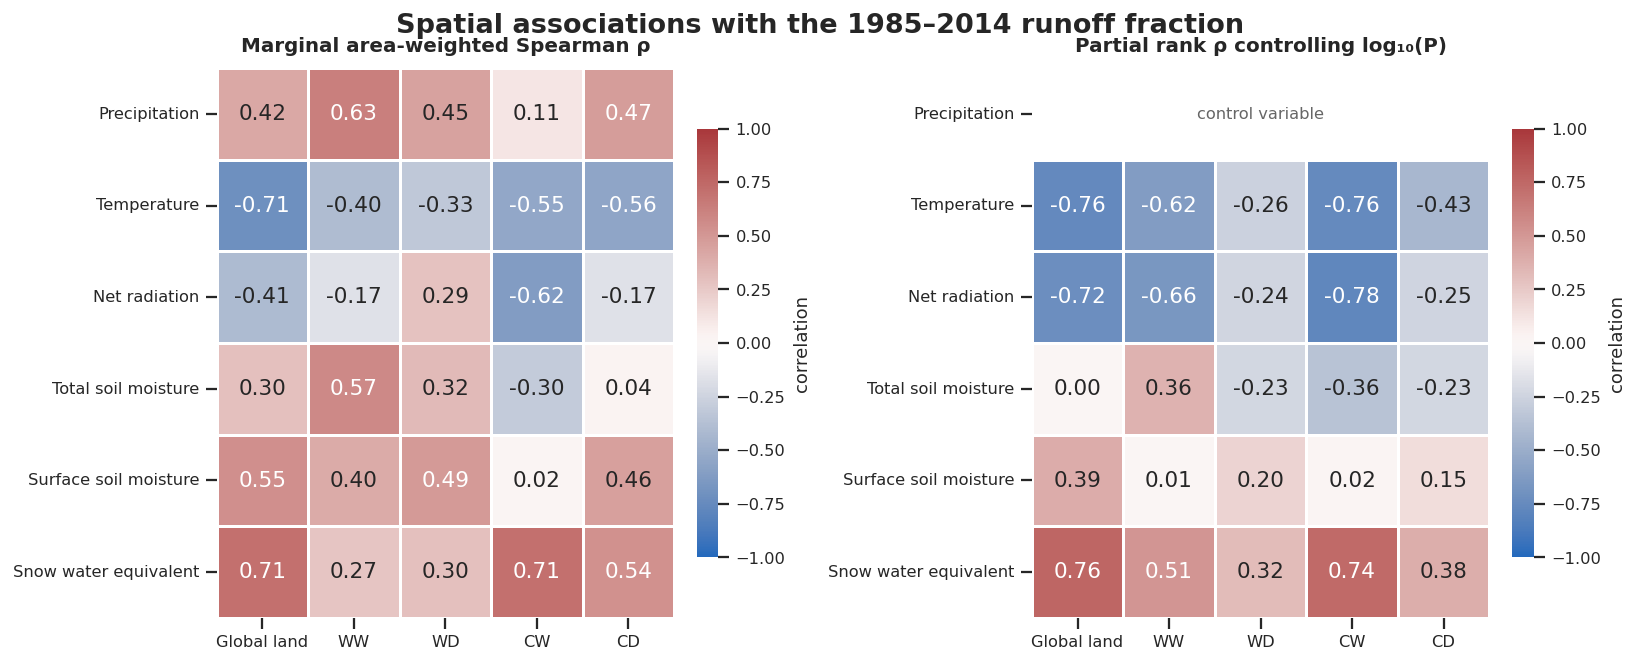

Saved: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/derived/figures_step6/driver_runoff_fraction_correlations.png


In [6]:
def weighted_corr(x, y, w):
    x, y, w = map(np.asarray, (x, y, w))
    valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(w) & (w > 0)
    x, y, w = x[valid], y[valid], w[valid]
    w = w / w.sum()
    dx, dy = x - np.sum(w * x), y - np.sum(w * y)
    denom = np.sqrt(np.sum(w * dx * dx) * np.sum(w * dy * dy))
    return np.sum(w * dx * dy) / denom if denom > 0 else np.nan

def weighted_spearman(x, y, w):
    return weighted_corr(pd.Series(x).rank(method="average"), pd.Series(y).rank(method="average"), w)

def weighted_residual(y, z, w):
    y, z, w = map(np.asarray, (y, z, w))
    X = np.column_stack([np.ones(len(z)), z])
    sw = np.sqrt(w / np.nanmean(w))
    beta = np.linalg.lstsq(X * sw[:, None], y * sw, rcond=None)[0]
    return y - X @ beta

def weighted_partial_spearman(x, y, control, w):
    frame = pd.DataFrame({"x": x, "y": y, "z": control, "w": w}).dropna()
    rx = frame["x"].rank(method="average").to_numpy()
    ry = frame["y"].rank(method="average").to_numpy()
    rz = frame["z"].rank(method="average").to_numpy()
    weights = frame["w"].to_numpy()
    return weighted_corr(weighted_residual(rx, rz, weights), weighted_residual(ry, rz, weights), weights)

predictors = {
    "Precipitation": "P",
    "Temperature": "tas_C",
    "Net radiation": "net_radiation",
    "Total soil moisture": "mrso",
    "Surface soil moisture": "mrsos",
    "Snow water equivalent": "snw",
}
rows = []
groups = [("Global land", analysis)] + [(zone, analysis[analysis["zone"] == zone]) for zone in ZONE_ORDER]
for group_name, subset in groups:
    w = subset["land_area"].to_numpy()
    y = subset["R_fraction_climatology"].to_numpy()
    for label, column in predictors.items():
        marginal = weighted_spearman(subset[column], y, w)
        partial = np.nan if column == "P" else weighted_partial_spearman(subset[column], y, subset["log10_P"], w)
        rows.append({"region": group_name, "predictor": label, "rho_marginal": marginal, "rho_partial_P": partial, "n_cells": len(subset)})
correlations = pd.DataFrame(rows)
CORR_OUTPUT = DERIVED_DIR / "MPI_ESM1_2_LR_driver_runoff_fraction_correlations_1985_2014.csv"
correlations.to_csv(CORR_OUTPUT, index=False)
display(correlations.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), constrained_layout=True)
for ax, value, title in zip(axes, ["rho_marginal", "rho_partial_P"], ["Marginal area-weighted Spearman ρ", "Partial rank ρ controlling log₁₀(P)"]):
    matrix = correlations.pivot(index="predictor", columns="region", values=value).reindex(index=list(predictors), columns=["Global land"] + ZONE_ORDER)
    sns.heatmap(matrix, ax=ax, cmap="vlag", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f", linewidths=0.8, linecolor="white", cbar_kws={"label": "correlation", "shrink": 0.78})
    if value == "rho_partial_P":
        ax.text(2.5, 0.5, "control variable", ha="center", va="center", color="#666666", fontsize=9)
    ax.set_title(title, pad=9)
    ax.set_xlabel("")
    ax.set_ylabel("")
fig.suptitle("Spatial associations with the 1985–2014 runoff fraction", fontsize=15, fontweight="bold", y=1.03)
path = FIGURE_DIR / "driver_runoff_fraction_correlations.png"
fig.savefig(path, bbox_inches="tight")
plt.show()
print(f"Saved: {path}")

## 7. Grid-cell scatterplots by Köppen proxy zone / 按 Köppen 代理区绘制逐网格散点

**English.** Each point is one CMIP grid cell. The solid curve connects medians in predictor quantile bins; it is a descriptive guide rather than a fitted physical law. All four panels use the same axes so that zone differences remain visually comparable.

**中文。** 每一个点都是一个 CMIP 网格。实线连接解释变量分位数分箱后的中位数，只用于显示关系形状，不代表拟合出的物理定律。四个面板使用相同坐标范围，便于直接比较不同气候区。

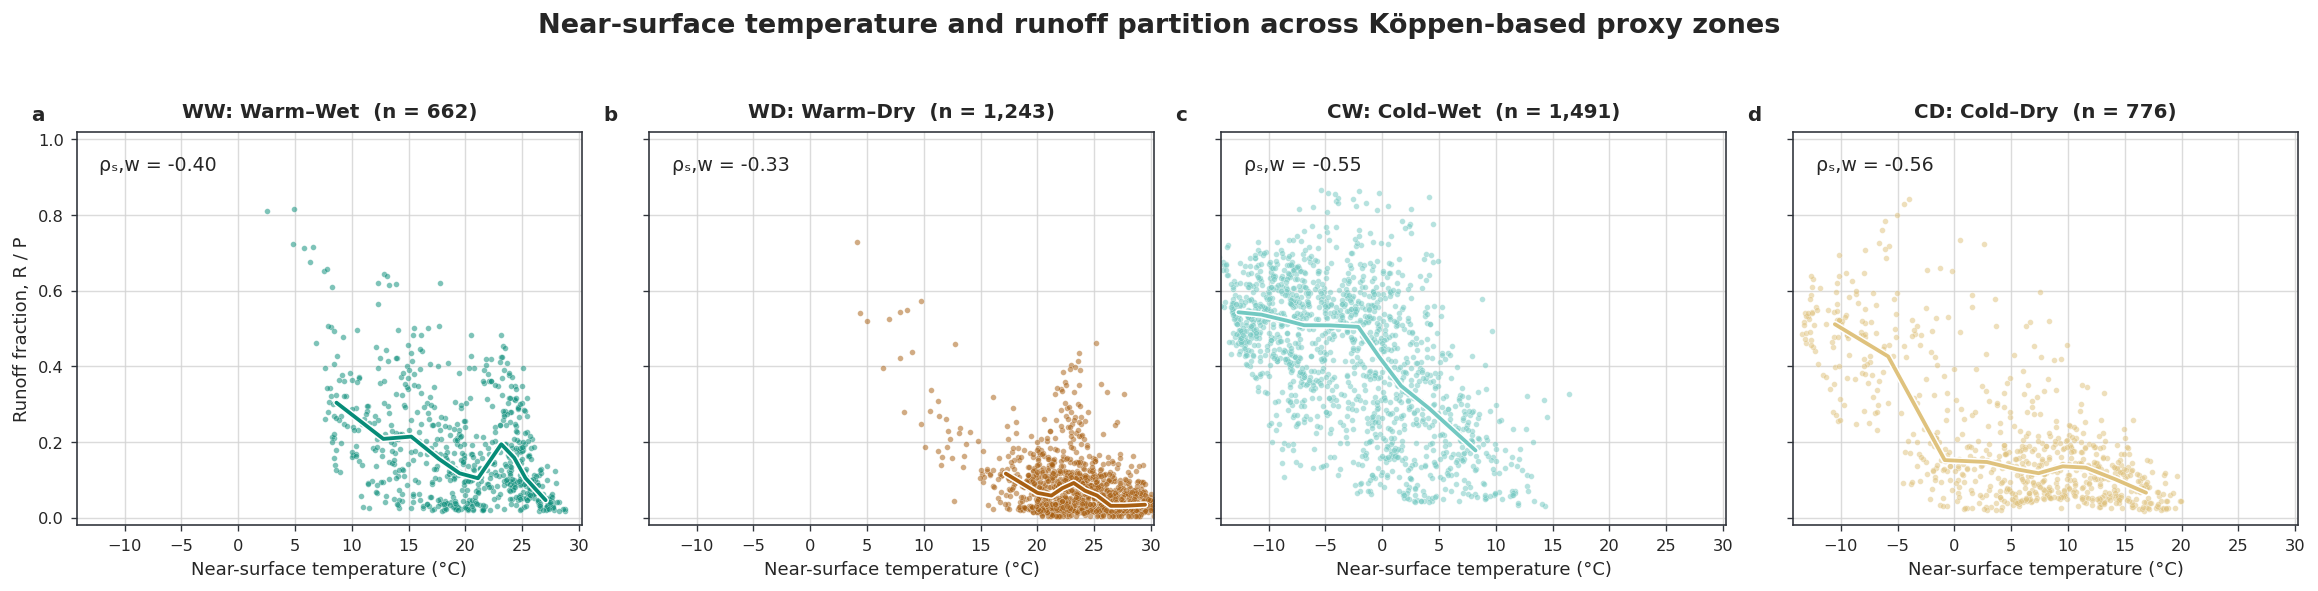

Saved: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/derived/figures_step6/temperature_vs_runoff_fraction.png


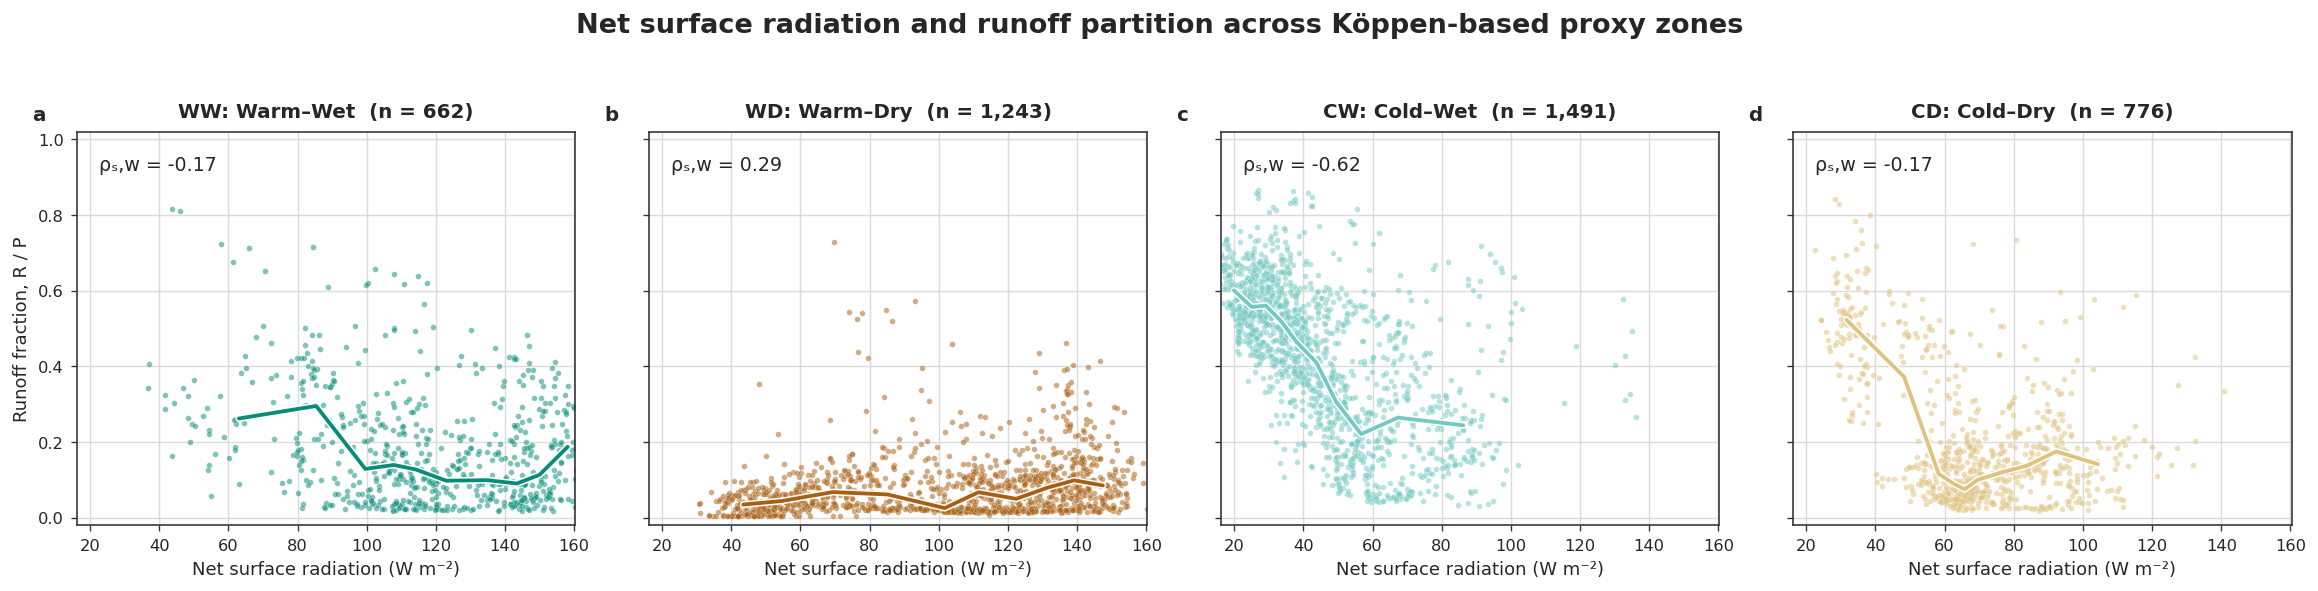

Saved: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/derived/figures_step6/net_radiation_vs_runoff_fraction.png


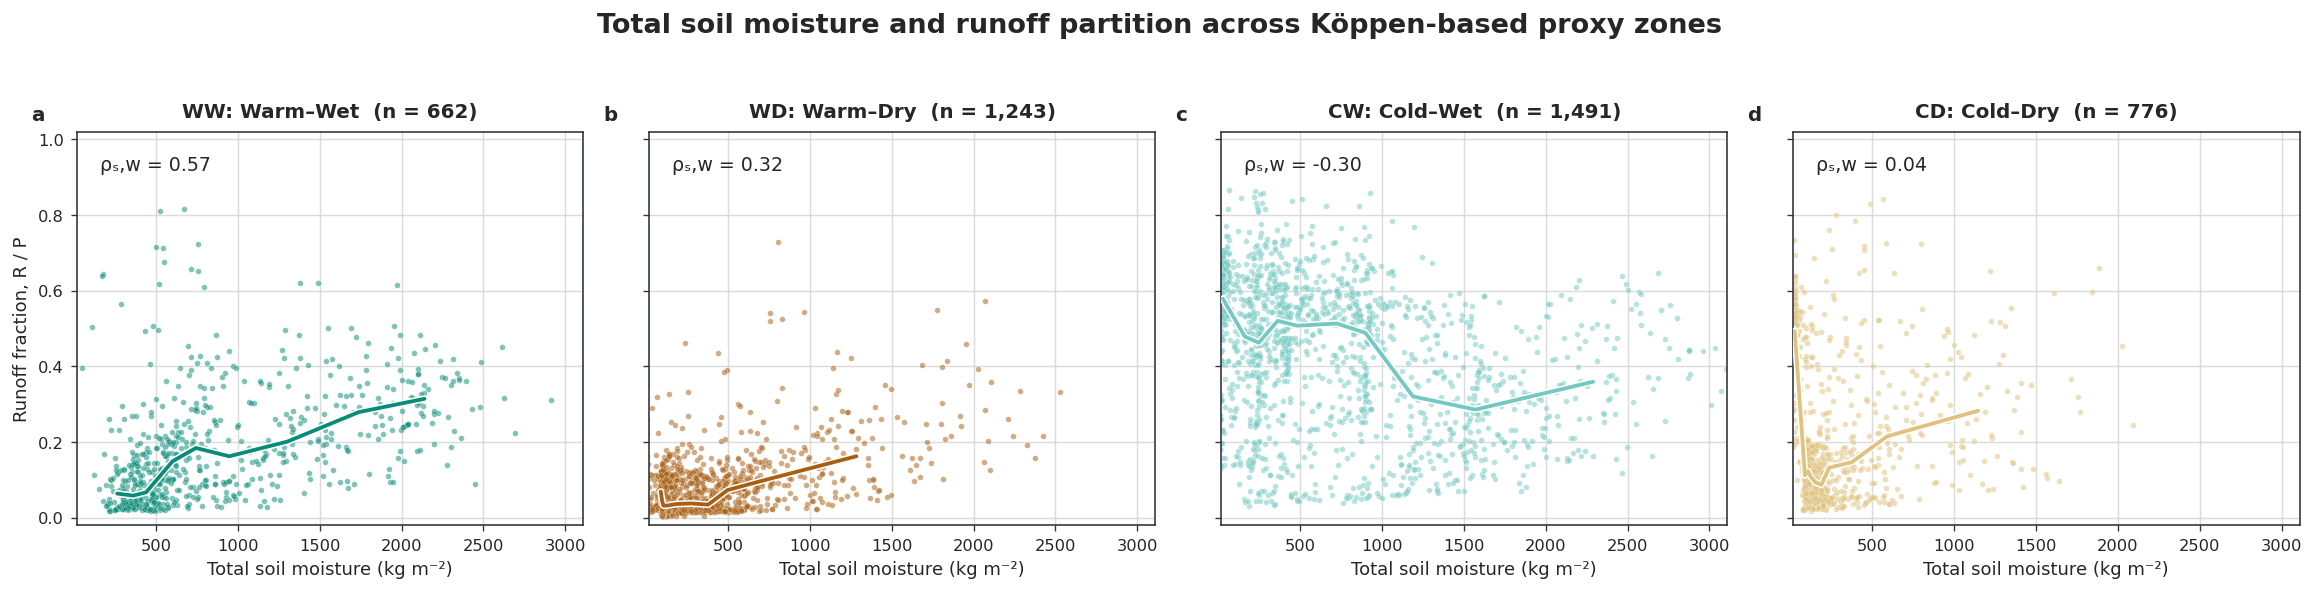

Saved: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/derived/figures_step6/soil_moisture_vs_runoff_fraction.png


In [7]:
def binned_medians(x, y, bins=10):
    frame = pd.DataFrame({"x": x, "y": y}).dropna().sort_values("x")
    frame["bin"] = pd.qcut(frame["x"], q=min(bins, frame["x"].nunique()), duplicates="drop")
    return frame.groupby("bin", observed=True)[["x", "y"]].median()

def zone_scatter_1x4(column, label, unit, filename):
    fig, axes = plt.subplots(1, 4, figsize=(18, 4.4), sharex=True, sharey=True)
    x_all = analysis[column].to_numpy()
    xlim = np.nanpercentile(x_all, [0.5, 99.5])
    for index, (ax, zone) in enumerate(zip(axes, ZONE_ORDER)):
        subset = analysis[analysis["zone"] == zone]
        color = ZONE_COLORS[zone]
        ax.scatter(subset[column], subset["R_fraction_climatology"], s=10, alpha=0.52, color=color, edgecolors="white", linewidths=0.22, rasterized=True, zorder=2)
        curve = binned_medians(subset[column], subset["R_fraction_climatology"])
        ax.plot(curve["x"], curve["y"], color="white", linewidth=3.8, zorder=3)
        ax.plot(curve["x"], curve["y"], color=color, linewidth=2.1, zorder=4)
        rho = weighted_spearman(subset[column], subset["R_fraction_climatology"], subset["land_area"])
        ax.text(0.045, 0.94, f"ρₛ,w = {rho:.2f}", transform=ax.transAxes, va="top", fontsize=10.5)
        ax.text(-0.09, 1.03, chr(97 + index), transform=ax.transAxes, fontsize=11, fontweight="bold")
        ax.set_title(f"{zone}: {ZONE_LABELS[zone]}  (n = {len(subset):,})", pad=8)
        ax.set_xlim(xlim)
        ax.set_ylim(-0.02, 1.02)
        ax.set_xlabel(f"{label} ({unit})")
        style_axes(ax)
    axes[0].set_ylabel("Runoff fraction, R / P")
    fig.suptitle(f"{label} and runoff partition across Köppen-based proxy zones", fontsize=15, fontweight="bold", y=1.03)
    fig.tight_layout()
    path = FIGURE_DIR / filename
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path}")

zone_scatter_1x4("tas_C", "Near-surface temperature", "°C", "temperature_vs_runoff_fraction.png")
zone_scatter_1x4("net_radiation", "Net surface radiation", "W m⁻²", "net_radiation_vs_runoff_fraction.png")
zone_scatter_1x4("mrso", "Total soil moisture", "kg m⁻²", "soil_moisture_vs_runoff_fraction.png")

## 8. Absolute runoff versus runoff fraction / 绝对径流与径流比例的直接对照

**English.** This figure uses the same grid cells twice. The upper row asks whether wetter cells produce more runoff in absolute units. The lower row asks what share of precipitation becomes runoff. Contrasting the rows prevents a large runoff amount from being mistaken for a large runoff fraction.

**中文。** 这张图对同一批网格进行两种比较。上排回答“降水更多的地方是否产生更多绝对径流量”；下排回答“降水中有多大比例转化为径流”。上下对照可以避免把“径流量大”误解为“径流占比高”。

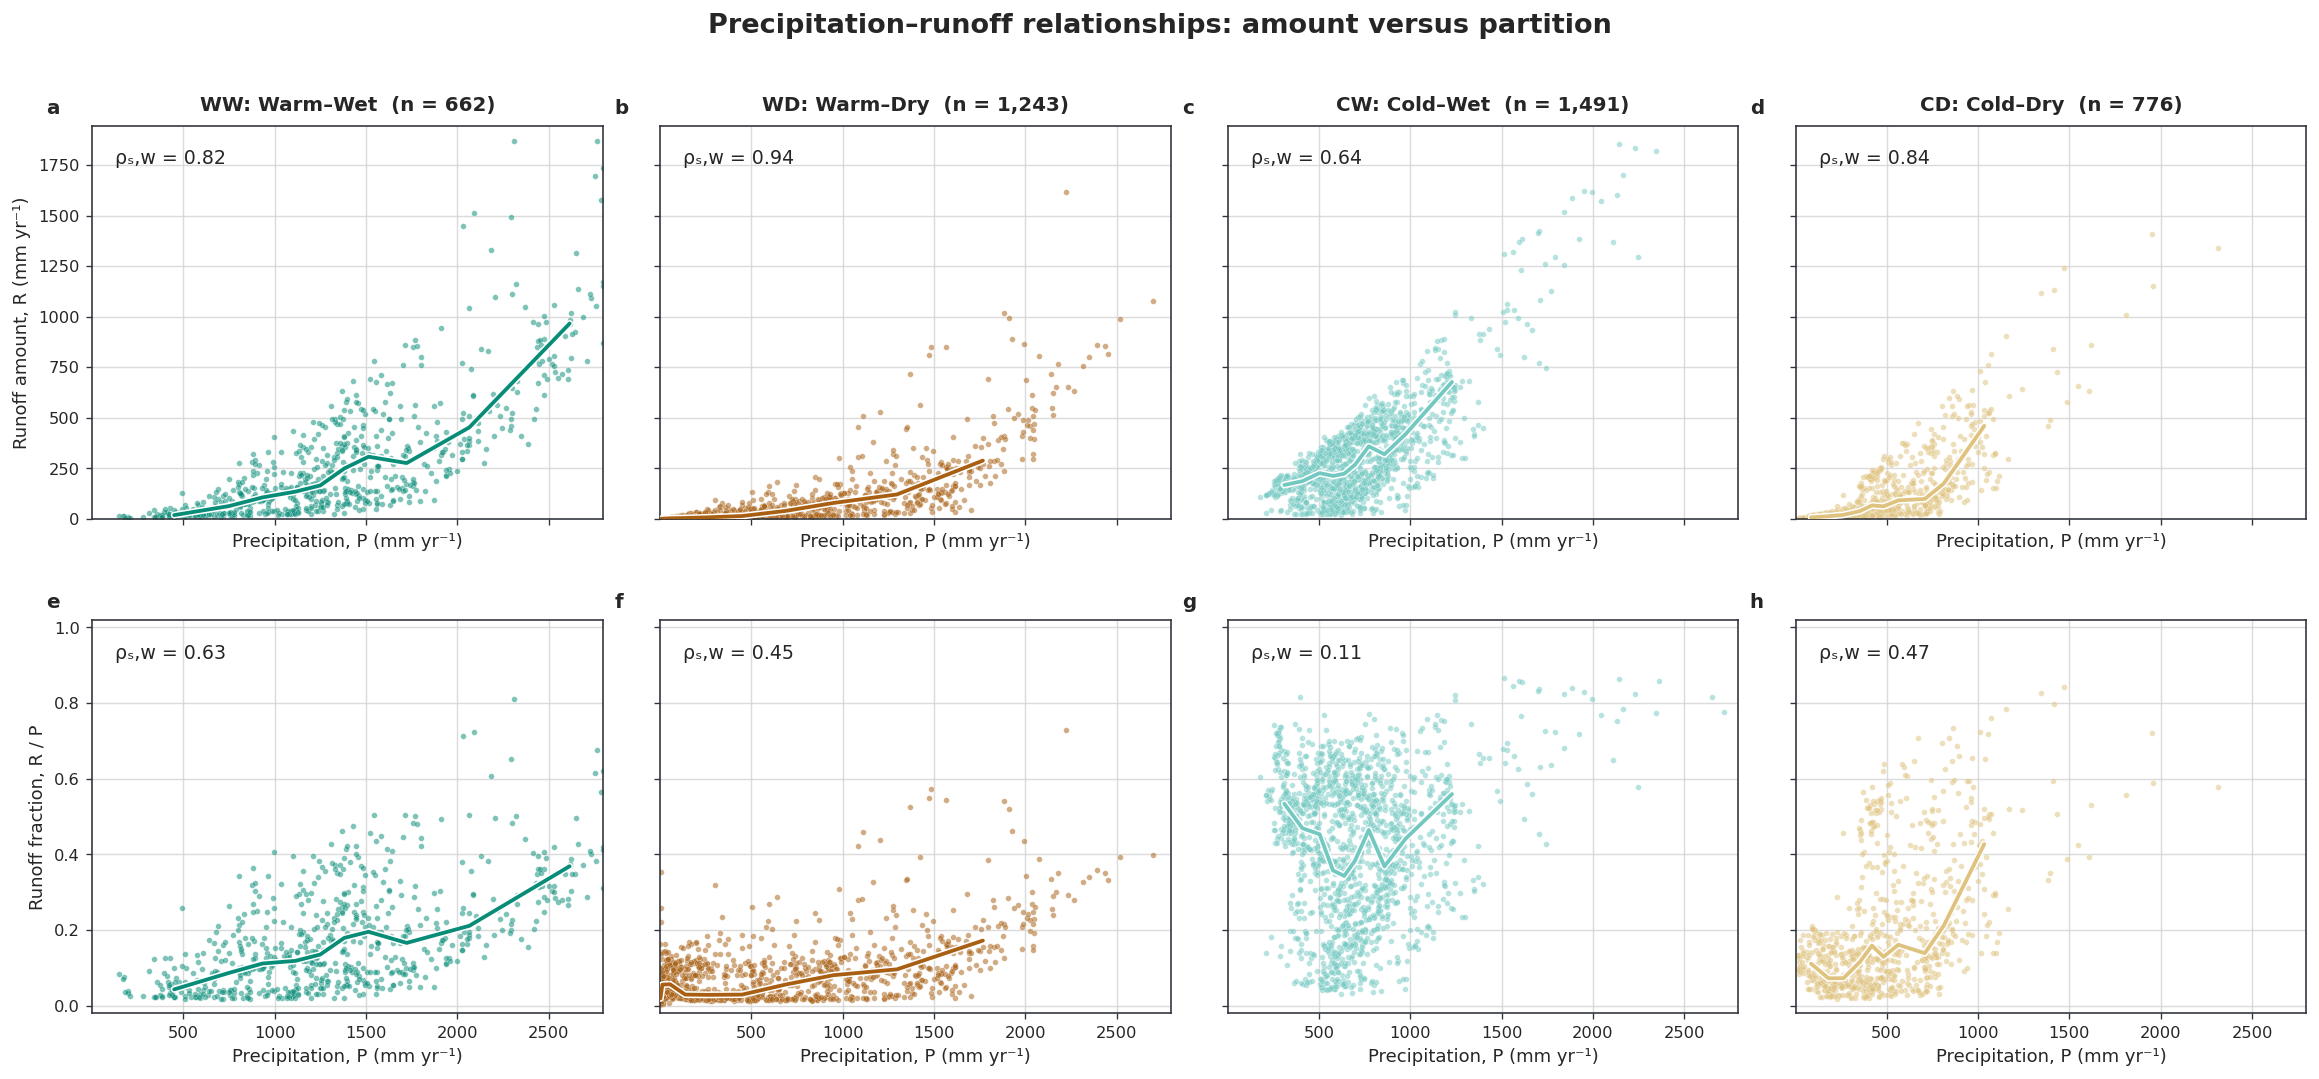

Saved: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/derived/figures_step6/precipitation_runoff_amount_vs_fraction.png


In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8.2), sharex=True, sharey="row")
xlim = np.nanpercentile(analysis["P"], [0.5, 99.5])
runoff_ylim = (0, np.nanpercentile(analysis["R"], 99.7) * 1.04)
targets = [
    ("R", "Runoff amount, R (mm yr⁻¹)", runoff_ylim),
    ("R_fraction_climatology", "Runoff fraction, R / P", (-0.02, 1.02)),
]
for row, (target, ylabel, ylim) in enumerate(targets):
    for col, zone in enumerate(ZONE_ORDER):
        ax = axes[row, col]
        subset = analysis[analysis["zone"] == zone]
        color = ZONE_COLORS[zone]
        ax.scatter(subset["P"], subset[target], s=10, alpha=0.52, color=color, edgecolors="white", linewidths=0.22, rasterized=True, zorder=2)
        curve = binned_medians(subset["P"], subset[target])
        ax.plot(curve["x"], curve["y"], color="white", linewidth=3.8, zorder=3)
        ax.plot(curve["x"], curve["y"], color=color, linewidth=2.1, zorder=4)
        rho = weighted_spearman(subset["P"], subset[target], subset["land_area"])
        ax.text(0.045, 0.94, f"ρₛ,w = {rho:.2f}", transform=ax.transAxes, va="top", fontsize=10.5)
        ax.text(-0.09, 1.03, chr(97 + row * 4 + col), transform=ax.transAxes, fontsize=11, fontweight="bold")
        if row == 0:
            ax.set_title(f"{zone}: {ZONE_LABELS[zone]}  (n = {len(subset):,})", pad=8)
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.set_xlabel("Precipitation, P (mm yr⁻¹)")
        style_axes(ax)
    axes[row, 0].set_ylabel(ylabel)
fig.suptitle("Precipitation–runoff relationships: amount versus partition", fontsize=15, fontweight="bold", y=1.01)
fig.tight_layout(h_pad=2.0, w_pad=1.0)
path = FIGURE_DIR / "precipitation_runoff_amount_vs_fraction.png"
fig.savefig(path, bbox_inches="tight")
plt.show()
print(f"Saved: {path}")

## 9. Zone-level summary / 气候区汇总

**English.** The final table reports land-area-weighted means. It is useful for describing regime contrasts, but it should not replace the grid-cell distributions above.

**中文。** 最后的表格给出陆地面积加权平均，用于概括不同区之间的整体差异，但不能替代上面的逐网格分布。

In [9]:
def weighted_mean(values, weights):
    values, weights = np.asarray(values), np.asarray(weights)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    return np.average(values[valid], weights=weights[valid])

summary_rows = []
summary_columns = ["P", "R_fraction_climatology", "tas_C", "net_radiation", "mrso", "mrsos", "snw"]
for zone in ZONE_ORDER:
    subset = analysis[analysis["zone"] == zone]
    row = {"zone": zone, "zone_label": ZONE_LABELS[zone], "n_cells": len(subset), "land_area_m2": subset["land_area"].sum()}
    for column in summary_columns:
        row[column] = weighted_mean(subset[column], subset["land_area"])
    summary_rows.append(row)
zone_summary = pd.DataFrame(summary_rows)
SUMMARY_OUTPUT = DERIVED_DIR / "MPI_ESM1_2_LR_driver_zone_summary_1985_2014.csv"
zone_summary.to_csv(SUMMARY_OUTPUT, index=False)
display(zone_summary.round({"P": 1, "R_fraction_climatology": 3, "tas_C": 2, "net_radiation": 1, "mrso": 1, "mrsos": 1, "snw": 1}))
print(f"Saved: {SUMMARY_OUTPUT}")

,zone,zone_label,n_cells,land_area_m2,P,R_fraction_climatology,tas_C,net_radiation,mrso,mrsos,snw
0,WW,Warm–Wet,662,2.582640e+13,1418.199951,0.182,20.02,121.1,901.8,24.2,0.1
1,WD,Warm–Dry,1243,4.991146e+13,586.599976,0.079,23.70,101.8,395.2,13.2,0.0
2,CW,Cold–Wet,1491,3.252974e+13,770.400024,0.401,-1.65,50.7,836.1,23.8,35.4
3,CD,Cold–Dry,776,2.306673e+13,492.600006,0.185,6.42,72.8,304.4,16.9,9.8


Saved: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/derived/MPI_ESM1_2_LR_driver_zone_summary_1985_2014.csv


## 10. Interpretation guardrails and next decision / 解释边界与下一步判断

**English**

1. $R/P$ and $ET/P$ are nearly complementary under long-term water balance, so they should not be treated as independent targets.
2. Soil moisture and snow are model state variables that respond to the water cycle as well as influence it. Their correlations are diagnostic, not clean external forcing effects.
3. Spatial correlations mix process relationships with geography. The precipitation-controlled result is a sensitivity check, not proof of causality.
4. A useful next step is to select predictors whose relationships remain stable within zones and after precipitation control. Only then should a tree be used to test nonlinear thresholds and interactions.

**中文**

1. 在长期水量平衡近似成立时，$R/P$ 与 $ET/P$ 基本互补，因此不应把二者当作两个独立目标。
2. 土壤水分和雪既会影响水循环，也会被水循环影响；它们是模型状态变量，相关结果适合诊断，不能直接解释为外部强迫效应。
3. 空间相关同时混合了过程关系和地理格局。控制降水后的结果只是稳健性检查，并不是因果证据。
4. 下一步应先挑出在不同气候区内、并且控制降水后仍较稳定的变量，再用 tree 检查非线性阈值与变量交互。